# **Machine Learning**

## Import dataset

In [1]:
# Import libraries
from pathlib import Path
import pandas as pd
import numpy as np
from src.models.preprocessing import preprocessing

In [2]:
# Loading the data
input_path = Path("..") / 'data' / 'processed' / 'dataset_processed.csv'
df = pd.read_csv(input_path)
df = df.set_index("date_index", drop=False)
df.index = pd.to_datetime(df.index)
display(df.columns)

Index(['latitude', 'longitude', 'temperature_2m_max', 'sunrise', 'sunset',
       'daylight_duration', 'precipitation_sum', 'shortwave_radiation_sum',
       'et0_fao_evapotranspiration', 'cloud_cover_mean', 'pressure_msl_mean',
       'wind_speed_10m_mean', 'soil_moisture_0_to_100cm_mean',
       'soil_temperature_0_to_100cm_mean', 'code_bss', 'date_index', 'bss_id',
       'niveau_nappe_eau', 'mode_obtention', 'nom_producteur', 'P_cum_30d',
       'P_cum_90d', 'Peff_cum_30d', 'Peff_cum_90d', 'Temperature_mean_30d',
       'Temperature_mean_90d', 'SPLI', 'SPI', 'SETI', 'SSTI', 'SSRI', 'SWSI',
       'SCCI', 'SPMI', 'SPEI', 'SSMI'],
      dtype='object')

In [3]:
df.columns.tolist()

['latitude',
 'longitude',
 'temperature_2m_max',
 'sunrise',
 'sunset',
 'daylight_duration',
 'precipitation_sum',
 'shortwave_radiation_sum',
 'et0_fao_evapotranspiration',
 'cloud_cover_mean',
 'pressure_msl_mean',
 'wind_speed_10m_mean',
 'soil_moisture_0_to_100cm_mean',
 'soil_temperature_0_to_100cm_mean',
 'code_bss',
 'date_index',
 'bss_id',
 'niveau_nappe_eau',
 'mode_obtention',
 'nom_producteur',
 'P_cum_30d',
 'P_cum_90d',
 'Peff_cum_30d',
 'Peff_cum_90d',
 'Temperature_mean_30d',
 'Temperature_mean_90d',
 'SPLI',
 'SPI',
 'SETI',
 'SSTI',
 'SSRI',
 'SWSI',
 'SCCI',
 'SPMI',
 'SPEI',
 'SSMI']

In [4]:
df.head(5)

,latitude,longitude,temperature_2m_max,sunrise,sunset,daylight_duration,precipitation_sum,shortwave_radiation_sum,et0_fao_evapotranspiration,cloud_cover_mean,...,SPLI,SPI,SETI,SSTI,SSRI,SWSI,SCCI,SPMI,SPEI,SSMI
date_index,,,,,,,,,,,,,,,,,,,,,
2017-01-01,42.685696,2.685378,9.8,2017-01-01T07:19,2017-01-01T16:26,32800.70,0.0,7.88,0.95,47,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
2017-01-02,42.685696,2.685378,9.0,2017-01-02T07:19,2017-01-02T16:27,32850.58,0.0,4.29,0.56,93,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
2017-01-03,42.685696,2.685378,11.7,2017-01-03T07:19,2017-01-03T16:28,32904.28,0.0,8.02,1.59,3,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
2017-01-04,42.685696,2.685378,10.6,2017-01-04T07:19,2017-01-04T16:29,32961.75,0.0,8.08,2.52,5,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164
2017-01-05,42.685696,2.685378,7.1,2017-01-05T07:19,2017-01-05T16:30,33022.91,0.0,6.93,2.07,14,...,0.124164,0.66519,0.380523,-1.018795,-0.124164,0.66519,-1.018795,0.66519,0.66519,0.124164


## XGBoost Regressor

In [5]:
# Import libraries
#from src.models.preprocessing import preprocessing
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [6]:
X_train, X_test, y_train, y_test = preprocessing(df, test_size=30)

In [7]:
def xgboost_regressor(df, n_estimators=100, learning_rate=0.1, max_depth=4,
                      subsample=0.8, colsample_bytree=0.8, random_state=42):
    """
    XGBoost Regressor predicting groundwater level (niveau_nappe_eau).
    Returns predictions and evaluation metrics (R2_train, R2_test, RMSE, MAE).
    """
    X_train, X_test, y_train, y_test = preprocessing(df, test_size=30)

    # --- Model ---
    model = XGBRegressor(
        n_estimators     = n_estimators,
        learning_rate    = learning_rate,
        max_depth        = max_depth,
        subsample        = subsample,
        colsample_bytree = colsample_bytree,
        random_state     = random_state
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # --- Predictions ---
    predictions_xgboost_reg = pd.DataFrame({
        "y_test" : y_test.values,
        "y_pred" : y_pred
    }, index=y_test.index)

    # --- Metrics ---
    evaluation_metrics_xgboost_reg = pd.DataFrame({
        "R2_train" : [model.score(X_train, y_train)],
        "R2_test"  : [model.score(X_test, y_test)],
        "RMSE"     : [np.sqrt(mean_squared_error(y_test, y_pred))],
        "MAE"      : [mean_absolute_error(y_test, y_pred)],
        "MAPE"     : [np.mean(np.abs((y_test - y_pred) / y_test)) * 100],
        "Biais"    : [np.mean(y_pred - y_test.values)]
    }, index=["niveau_nappe_eau"])

    return predictions_xgboost_reg, evaluation_metrics_xgboost_reg

In [8]:
predictions_xgboost_reg, evaluation_metrics_xgboost_reg = xgboost_regressor(df)

In [9]:
predictions_xgboost_reg

,y_test,y_pred
date_index,,
2026-06-20,104.15,103.481224
2026-06-21,104.16,103.329178
2026-06-22,104.13,103.484123
2026-06-23,104.14,103.484123
2026-06-24,104.15,103.647995
2026-06-25,104.15,103.629524
2026-06-26,104.15,103.606506
2026-06-27,104.12,103.721100
2026-06-28,104.13,103.679138


In [10]:
evaluation_metrics_xgboost_reg

,R2_train,R2_test,RMSE,MAE,MAPE,Biais
niveau_nappe_eau,0.842575,-22.1237,0.550849,0.536315,0.515504,-0.536315


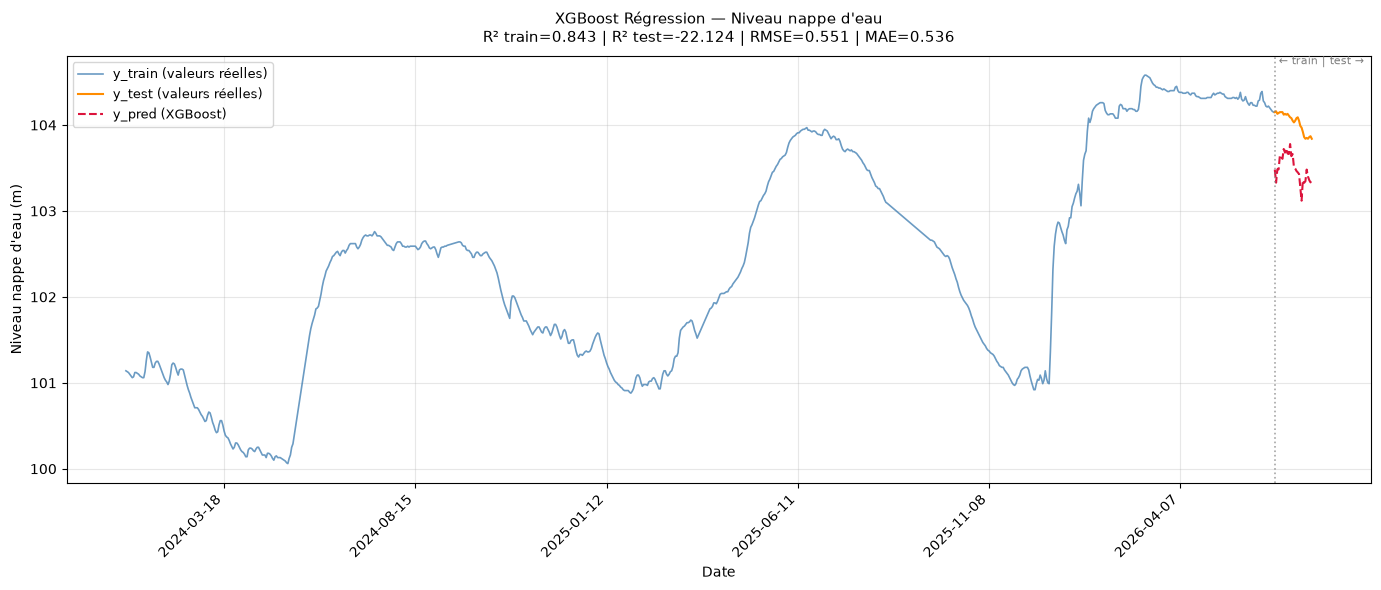

In [11]:
plot_start = "2024-01-01"  # ← modifie cette date si besoin, ou None pour tout afficher

# --- Filtrage optionnel de la date de début ---
y_train_plot = y_train[y_train.index >= pd.Timestamp(plot_start)] if plot_start else y_train

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(y_train_plot.index, y_train_plot.values,
        color="steelblue", linewidth=1.2, alpha=0.8,
        label="y_train (valeurs réelles)")

ax.plot(predictions_xgboost_reg.index, predictions_xgboost_reg["y_test"],
        color="darkorange", linewidth=1.5,
        label="y_test (valeurs réelles)")

ax.plot(predictions_xgboost_reg.index, predictions_xgboost_reg["y_pred"],
        color="crimson", linewidth=1.5, linestyle="--",
        label="y_pred (XGBoost)")

# --- Séparateur train / test ---
split_date = predictions_xgboost_reg.index[0]
ax.axvline(split_date, color="gray", linestyle=":", linewidth=1.2, alpha=0.7)
ax.text(split_date, ax.get_ylim()[1],
        " ← train | test →", fontsize=8, color="gray", va="top")

# --- Titre avec métriques ---
row = evaluation_metrics_xgboost_reg.iloc[0]
ax.set_title(
    f"XGBoost Régression — Niveau nappe d'eau\n"
    f"R² train={row['R2_train']:.3f} | R² test={row['R2_test']:.3f} | "
    f"RMSE={row['RMSE']:.3f} | MAE={row['MAE']:.3f}",
    fontsize=11, pad=10
)

# --- Axes sans mdates ---
ax.set_xlabel("Date")
ax.set_ylabel("Niveau nappe d'eau (m)")
ax.xaxis.set_major_locator(plt.MaxNLocator(10))  # ← max 10 ticks sur l'axe x
fig.autofmt_xdate(rotation=45)
ax.legend(loc="best", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Variance = moyenne des écarts au carré


**Interprétatoin**

Le R² est une métrique qui mesure la proportion de variance expliquée par le modèle. Quand la série cible est quasi-stationnaire — comme un niveau de nappe qui ne varie que de quelques centimètres sur 30 jours — sa variance totale est extrêmement faible. Or le R² divise l'erreur du modèle par cette variance : si le dénominateur est minuscule, le moindre décalage systématique suffit à faire exploser le ratio à la baisse, même si l'erreur absolue reste négligeable en regard de la valeur cible.

Dans notre cas, le modèle se trompe en moyenne de 0.54 m sur une nappe autour de 104 m, soit une erreur relative de 0.5% — ce que confirment le RMSE, le MAE et le MAPE. Pourtant le R² atteint -22, car la série de test est si plate que cette erreur de 54 cm représente plusieurs fois sa variance totale.

En d'autres termes, un R² négatif et extrême n'indique pas nécessairement un modèle inutile — il indique surtout que la métrique est inadaptée au problème. Sur une série temporelle à faible variabilité, le R² perd son pouvoir discriminant et seuls le RMSE, le MAE et le MAPE permettent d'évaluer correctement la qualité des prédictions.

# **Test avec rolling de 30 jours**

Train : 2017-01-01 → 2025-09-30 (3195 jours)
Test  : 2025-10-01 → 2025-10-31 (31 jours)

y_train mean=102.727  std=1.089
y_test  mean=102.090  std=0.320  var=0.1026

                  R2_train   R2_test      RMSE      MAE     MAPE    Biais  Variance
niveau_nappe_eau  0.850238 -8.681273  0.980421  0.92533  0.90728  0.92533  0.102597


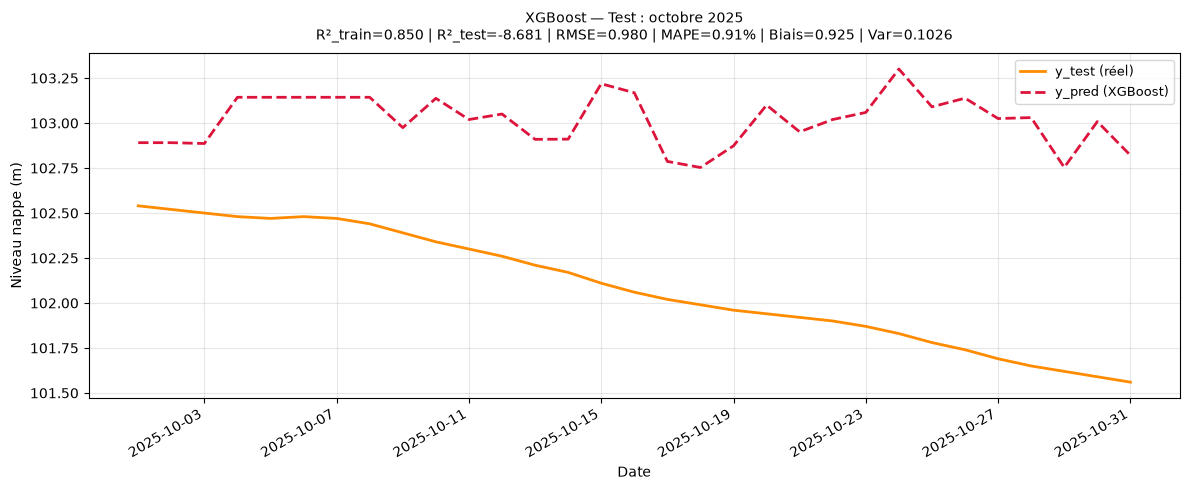

In [14]:
def xgboost_octobre_2025(df, n_estimators=100, learning_rate=0.1, max_depth=4,
                          subsample=0.8, colsample_bytree=0.8, random_state=42):
    """
    XGBoost Regressor — test set fixé sur octobre 2025.
    """
    # --- Preprocessing ---
    df = df.copy()
    df = df.set_index("date_index", drop=False)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    feature_cols = [
        "shortwave_radiation_sum",
        "et0_fao_evapotranspiration",
        "soil_temperature_0_to_100cm_mean",
        "P_cum_90d",
        "Peff_cum_90d",
        "Temperature_mean_90d"
    ]
    target_col = "niveau_nappe_eau"
    df = df[feature_cols + [target_col]].dropna()

    # --- Split : train = tout avant oct 2025, test = oct 2025 ---
    test_mask = (df.index.year == 2025) & (df.index.month == 10)
    df_train  = df[df.index < "2025-10-01"]
    df_test   = df[test_mask]

    X_train = df_train[feature_cols]
    y_train = df_train[target_col]
    X_test  = df_test[feature_cols]
    y_test  = df_test[target_col]

    print(f"Train : {y_train.index[0].date()} → {y_train.index[-1].date()} ({len(y_train)} jours)")
    print(f"Test  : {y_test.index[0].date()} → {y_test.index[-1].date()} ({len(y_test)} jours)")
    print(f"\ny_train mean={y_train.mean():.3f}  std={y_train.std():.3f}")
    print(f"y_test  mean={y_test.mean():.3f}  std={y_test.std():.3f}  var={y_test.var():.4f}")

    # --- Modèle ---
    model = XGBRegressor(
        n_estimators     = n_estimators,
        learning_rate    = learning_rate,
        max_depth        = max_depth,
        subsample        = subsample,
        colsample_bytree = colsample_bytree,
        random_state     = random_state
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # --- Prédictions ---
    predictions_df = pd.DataFrame({
        "y_test" : y_test.values,
        "y_pred" : y_pred
    }, index=y_test.index)

    # --- Métriques ---
    metrics_df = pd.DataFrame({
        "R2_train" : [model.score(X_train, y_train)],
        "R2_test"  : [r2_score(y_test, y_pred)],
        "RMSE"     : [np.sqrt(mean_squared_error(y_test, y_pred))],
        "MAE"      : [mean_absolute_error(y_test, y_pred)],
        "MAPE"     : [np.mean(np.abs((y_test - y_pred) / y_test)) * 100],
        "Biais"    : [np.mean(y_pred - y_test.values)],
        "Variance" : [y_test.var()]
    }, index=["niveau_nappe_eau"])

    print(f"\n{metrics_df.to_string()}")

    # --- Visualisation ---
    fig, ax = plt.subplots(figsize=(12, 5))

    ax.plot(y_test.index, y_test.values,
            color="darkorange", linewidth=2, label="y_test (réel)")
    ax.plot(y_test.index, y_pred,
            color="crimson", linewidth=2, linestyle="--", label="y_pred (XGBoost)")

    row = metrics_df.iloc[0]
    ax.set_title(
        f"XGBoost — Test : octobre 2025\n"
        f"R²_train={row['R2_train']:.3f} | R²_test={row['R2_test']:.3f} | "
        f"RMSE={row['RMSE']:.3f} | MAPE={row['MAPE']:.2f}% | "
        f"Biais={row['Biais']:.3f} | Var={row['Variance']:.4f}",
        fontsize=10, pad=10
    )
    ax.set_xlabel("Date")
    ax.set_ylabel("Niveau nappe (m)")
    ax.xaxis.set_major_locator(plt.MaxNLocator(10))
    fig.autofmt_xdate(rotation=45)
    fig.autofmt_xdate()
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return predictions_df, metrics_df


# ── Exécution ──────────────────────────────────────────────────────────────────
predictions_oct25, metrics_oct25 = xgboost_octobre_2025(df)

Dataset total : 3487 jours
Train initial : 2017-01-01 → 2024-08-20 (2789 jours)
Pool test     : 2024-08-21 → 2026-07-19 (698 jours)

Nombre de mois : 24

Fold 01 | 2024-08 | n_train=2789 | var=0.0014 | biais=+1.183 | R²_test=-1181.590 | MAPE=1.15%
Fold 02 | 2024-09 | n_train=2800 | var=0.0032 | biais=+1.049 | R²_test=-373.105 | MAPE=1.02%
Fold 03 | 2024-10 | n_train=2830 | var=0.0712 | biais=+1.275 | R²_test=-22.981 | MAPE=1.25%
Fold 04 | 2024-11 | n_train=2861 | var=0.0142 | biais=+0.867 | R²_test=-55.430 | MAPE=0.85%
Fold 05 | 2024-12 | n_train=2891 | var=0.0146 | biais=+0.600 | R²_test=-38.023 | MAPE=0.68%
Fold 06 | 2025-01 | n_train=2922 | var=0.0608 | biais=+0.458 | R²_test=-2.905 | MAPE=0.45%
Fold 07 | 2025-02 | n_train=2953 | var=0.0041 | biais=+1.029 | R²_test=-342.062 | MAPE=1.02%
Fold 08 | 2025-03 | n_train=2981 | var=0.0471 | biais=+0.398 | R²_test=-3.733 | MAPE=0.39%
Fold 09 | 2025-04 | n_train=3012 | var=0.0264 | biais=-0.084 | R²_test=-3.431 | MAPE=0.22%
Fold 10 | 2025-05

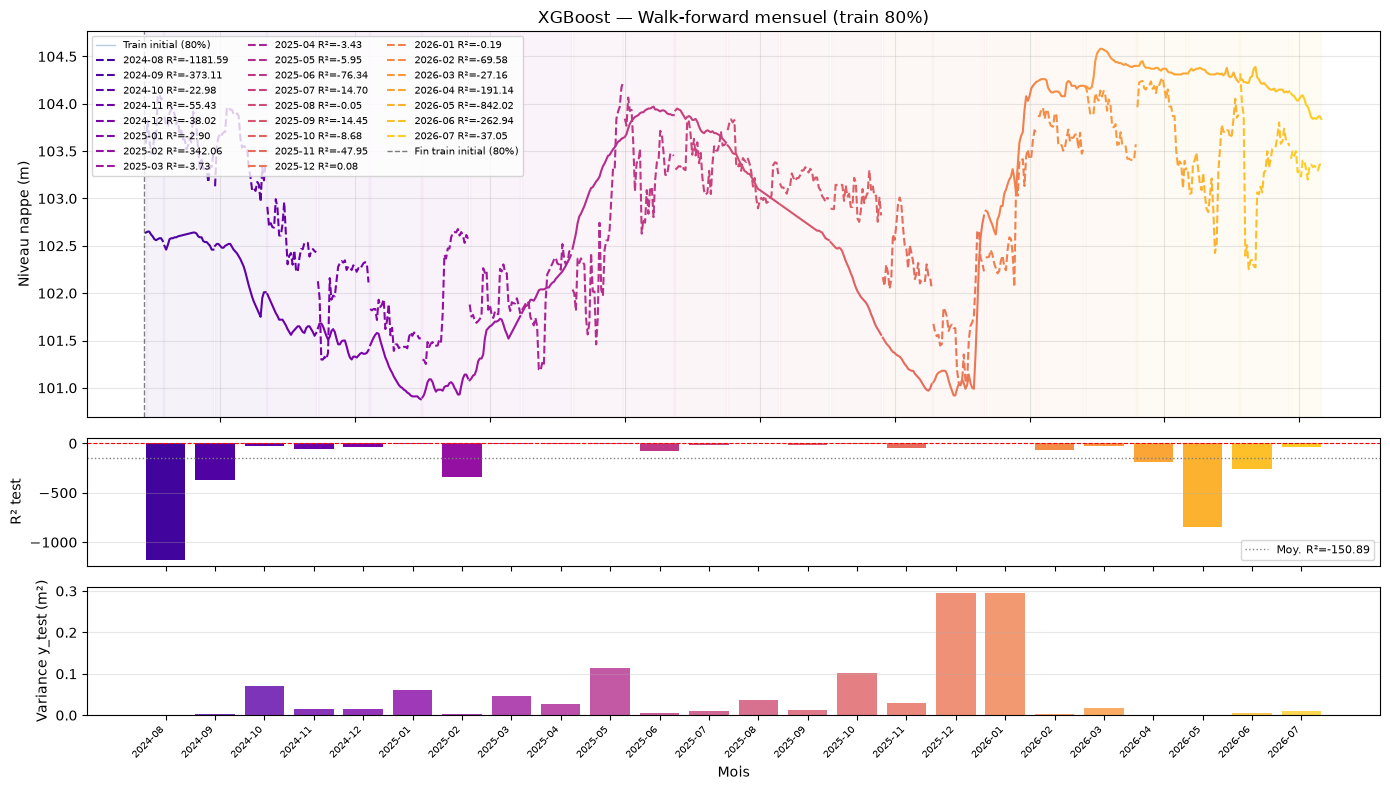

In [15]:
def xgboost_rolling_monthly(df, n_estimators=100, learning_rate=0.1,
                             max_depth=4, subsample=0.8, colsample_bytree=0.8,
                             random_state=42, figsize=(14, 8),
                             plot_start=None):
    """
    XGBoost walk-forward validation :
    - Train fixe : 80% du dataset
    - Test : fenêtres glissantes par mois calendaire sur les 20% restants
    - plot_start : str ou datetime, date de début du graphique (ex: "2024-01-01")
    Le train grandit à chaque fold (walk-forward).
    """
    # --- Preprocessing ---
    df = df.copy()
    df = df.set_index("date_index", drop=False)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    feature_cols = [
        "shortwave_radiation_sum",
        "et0_fao_evapotranspiration",
        "soil_temperature_0_to_100cm_mean",
        "P_cum_90d",
        "Peff_cum_90d",
        "Temperature_mean_90d"
    ]
    target_col = "niveau_nappe_eau"
    df = df[feature_cols + [target_col]].dropna()

    # --- Split 80/20 ---
    n             = len(df)
    train_cutoff  = int(n * 0.8)
    df_train_init = df.iloc[:train_cutoff]
    df_test_pool  = df.iloc[train_cutoff:]

    print(f"Dataset total : {n} jours")
    print(f"Train initial : {df_train_init.index[0].date()} → "
          f"{df_train_init.index[-1].date()} ({len(df_train_init)} jours)")
    print(f"Pool test     : {df_test_pool.index[0].date()} → "
          f"{df_test_pool.index[-1].date()} ({len(df_test_pool)} jours)\n")

    # --- Génération des fenêtres par mois calendaire ---
    months = df_test_pool.groupby([df_test_pool.index.year,
                                   df_test_pool.index.month])
    print(f"Nombre de mois : {len(months)}\n")

    all_metrics = []
    all_preds   = []

    for fold, ((year, month), df_test) in enumerate(months, start=1):

        # Walk-forward : train grandit en absorbant les mois précédents
        df_train = df[df.index < df_test.index[0]]

        X_train = df_train[feature_cols]
        y_train = df_train[target_col]
        X_test  = df_test[feature_cols]
        y_test  = df_test[target_col]

        # --- Modèle ---
        model = XGBRegressor(
            n_estimators     = n_estimators,
            learning_rate    = learning_rate,
            max_depth        = max_depth,
            subsample        = subsample,
            colsample_bytree = colsample_bytree,
            random_state     = random_state
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # --- Métriques ---
        metrics = {
            "fold"      : fold,
            "mois"      : f"{year}-{month:02d}",
            "date_start": y_test.index[0].date(),
            "date_end"  : y_test.index[-1].date(),
            "n_train"   : len(y_train),
            "n_test"    : len(y_test),
            "variance"  : float(y_test.var()),
            "R2_train"  : float(model.score(X_train, y_train)),
            "R2_test"   : float(r2_score(y_test, y_pred)),
            "RMSE"      : float(np.sqrt(mean_squared_error(y_test, y_pred))),
            "MAE"       : float(mean_absolute_error(y_test, y_pred)),
            "MAPE"      : float(np.mean(np.abs((y_test - y_pred) / y_test)) * 100),
            "Biais"     : float(np.mean(y_pred - y_test.values))
        }

        print(f"Fold {fold:02d} | {metrics['mois']} | "
              f"n_train={len(y_train)} | var={metrics['variance']:.4f} | "
              f"biais={metrics['Biais']:+.3f} | R²_test={metrics['R2_test']:+.3f} | "
              f"MAPE={metrics['MAPE']:.2f}%")

        all_metrics.append(metrics)
        all_preds.append(pd.DataFrame({
            "y_test" : y_test.values,
            "y_pred" : y_pred,
            "fold"   : fold,
            "mois"   : metrics["mois"]
        }, index=y_test.index))

    metrics_df   = pd.DataFrame(all_metrics).set_index("fold")
    all_preds_df = pd.concat(all_preds)

    # --- Résumé ---
    print(f"\n{'='*70}")
    print(f"R²_test  moyen : {metrics_df['R2_test'].mean():.3f} "
          f"± {metrics_df['R2_test'].std():.3f}")
    print(f"MAPE     moyen : {metrics_df['MAPE'].mean():.2f}%")
    print(f"Biais    moyen : {metrics_df['Biais'].mean():+.3f} m")
    print(f"Variance moy.  : {metrics_df['variance'].mean():.4f} m²")
    
    # --- Résumé global sous forme de DataFrame ---
    summary_df = pd.DataFrame({
        "R2_train" : [metrics_df["R2_train"].mean()],
        "R2_test"  : [metrics_df["R2_test"].mean()],
        "RMSE"     : [metrics_df["RMSE"].mean()],
        "MAE"      : [metrics_df["MAE"].mean()],
        "MAPE"     : [metrics_df["MAPE"].mean()],
        "Biais"    : [metrics_df["Biais"].mean()],
        "Variance" : [metrics_df["variance"].mean()]
    }, index=["moyenne_folds"])

    print(f"\n{summary_df.to_string()}")

    # --- Visualisation ---
    fig, axes = plt.subplots(3, 1, figsize=figsize,
                             gridspec_kw={"height_ratios": [3, 1, 1]})
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(metrics_df)))

    # --- Filtrage date de début du graphique ---
    train_plot = (df_train_init[df_train_init.index >= pd.Timestamp(plot_start)]
                  if plot_start else df_train_init)

    # Panneau 1 : séries temporelles
    ax1 = axes[0]
    ax1.plot(train_plot.index, train_plot[target_col],
             color="steelblue", linewidth=1, alpha=0.4,
             label="Train initial (80%)")

    for _, group in all_preds_df.groupby("fold"):
        fold_id = int(group["fold"].iloc[0])
        mois    = group["mois"].iloc[0]
        c       = colors[fold_id - 1]
        ax1.plot(group.index, group["y_test"],
                 color=c, linewidth=1.5)
        ax1.plot(group.index, group["y_pred"],
                 color=c, linewidth=1.5, linestyle="--",
                 label=f"{mois} R²={metrics_df.loc[fold_id, 'R2_test']:.2f}")
        ax1.axvspan(group.index[0], group.index[-1], alpha=0.05, color=c)

    ax1.axvline(df_train_init.index[-1], color="black", linestyle="--",
                linewidth=1, alpha=0.5, label="Fin train initial (80%)")
    ax1.set_ylabel("Niveau nappe (m)")
    ax1.set_title("XGBoost — Walk-forward mensuel (train 80%)")
    ax1.legend(loc="upper left", fontsize=7, ncol=3)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_locator(plt.MaxNLocator(12))
    fig.autofmt_xdate(rotation=45)

    # Panneau 2 : R² test par mois
    ax2 = axes[1]
    ax2.bar(metrics_df.index, metrics_df["R2_test"],
            color=colors[:len(metrics_df)])
    ax2.axhline(0, color="red", linewidth=0.8, linestyle="--")
    ax2.axhline(metrics_df["R2_test"].mean(), color="gray",
                linewidth=1, linestyle=":",
                label=f"Moy. R²={metrics_df['R2_test'].mean():.2f}")
    ax2.set_ylabel("R² test")
    ax2.set_xticks(metrics_df.index)
    ax2.set_xticklabels(metrics_df["mois"], rotation=45, fontsize=7)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3, axis="y")

    # Panneau 3 : variance du test par mois
    ax3 = axes[2]
    ax3.bar(metrics_df.index, metrics_df["variance"],
            color=colors[:len(metrics_df)], alpha=0.8)
    ax3.set_ylabel("Variance y_test (m²)")
    ax3.set_xlabel("Mois")
    ax3.set_xticks(metrics_df.index)
    ax3.set_xticklabels(metrics_df["mois"], rotation=45, fontsize=7)
    ax3.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

    return all_preds_df, metrics_df


# ── Exécution ──────────────────────────────────────────────────────────────────

# Affiche tout
#all_preds_df, metrics_df = xgboost_rolling_monthly(df)

# Affiche à partir de janvier 2024
all_preds_df, metrics_df = xgboost_rolling_monthly(df, plot_start="2026-01-01")

## Prediction sur l'année 2026 avec rolling de 30 jours

Train initial : 2017-01-01 → 2025-12-31 (3287 jours)
Pool test     : 2026-01-01 → 2026-07-19 (200 jours)

Nombre de mois : 7

Fold 01 | 2026-01 | n_train=3287 | var=0.2945 | biais=-0.534 | R²_test=-0.189 | MAPE=0.52%
Fold 02 | 2026-02 | n_train=3318 | var=0.0034 | biais=-0.464 | R²_test=-69.580 | MAPE=0.45%
Fold 03 | 2026-03 | n_train=3346 | var=0.0164 | biais=-0.604 | R²_test=-27.161 | MAPE=0.58%
Fold 04 | 2026-04 | n_train=3377 | var=0.0015 | biais=-0.410 | R²_test=-191.141 | MAPE=0.39%
Fold 05 | 2026-05 | n_train=3407 | var=0.0014 | biais=-0.979 | R²_test=-842.023 | MAPE=0.94%
Fold 06 | 2026-06 | n_train=3438 | var=0.0051 | biais=-0.956 | R²_test=-262.941 | MAPE=0.92%
Fold 07 | 2026-07 | n_train=3468 | var=0.0110 | biais=-0.620 | R²_test=-37.049 | MAPE=0.60%

R²_test  moyen : -204.298 ± 297.059
MAPE     moyen : 0.63%
Biais    moyen : -0.652 m
Variance moy.  : 0.0476 m²

               R2_train     R2_test      RMSE       MAE      MAPE     Biais  Variance
moyenne_folds  0.845446 -204

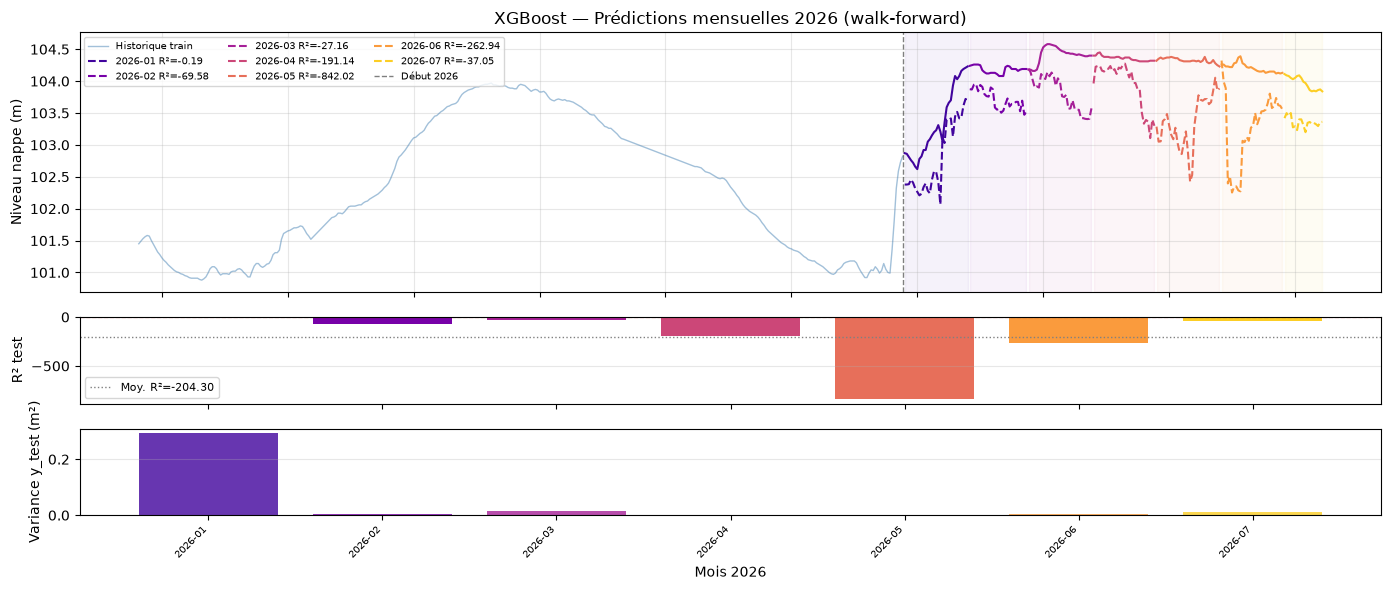

In [19]:
def xgboost_2026(df, n_estimators=100, learning_rate=0.1,
                 max_depth=4, subsample=0.8, colsample_bytree=0.8,
                 random_state=42, figsize=(14, 6), plot_start=None, plot_end=None):
    """
    XGBoost :
    - Train : toutes les données jusqu'au 31/12/2025
    - Test  : année 2026 en rolling mensuel (walk-forward)
    - Visualisation avec antériorité configurable via plot_start
    """
    # --- Preprocessing ---
    df = df.copy()
    df = df.set_index("date_index", drop=False)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    feature_cols = [
        "shortwave_radiation_sum",
        "et0_fao_evapotranspiration",
        "soil_temperature_0_to_100cm_mean",
        "P_cum_90d",
        "Peff_cum_90d",
        "Temperature_mean_90d"
    ]
    target_col = "niveau_nappe_eau"
    df = df[feature_cols + [target_col]].dropna()

    # --- Split : train jusqu'au 31/12/2025, test = 2026 ---
    df_train_init = df[df.index < "2026-01-01"]
    df_test_pool  = df[df.index >= "2026-01-01"]

    print(f"Train initial : {df_train_init.index[0].date()} → "
          f"{df_train_init.index[-1].date()} ({len(df_train_init)} jours)")
    print(f"Pool test     : {df_test_pool.index[0].date()} → "
          f"{df_test_pool.index[-1].date()} ({len(df_test_pool)} jours)\n")

    # --- Fenêtres mensuelles sur 2026 ---
    months = df_test_pool.groupby([df_test_pool.index.year,
                                   df_test_pool.index.month])
    print(f"Nombre de mois : {len(months)}\n")

    all_metrics = []
    all_preds   = []

    for fold, ((year, month), df_test) in enumerate(months, start=1):

        # Walk-forward : train grandit en absorbant les mois précédents
        df_train = df[df.index < df_test.index[0]]

        X_train = df_train[feature_cols]
        y_train = df_train[target_col]
        X_test  = df_test[feature_cols]
        y_test  = df_test[target_col]

        # --- Modèle ---
        model = XGBRegressor(
            n_estimators     = n_estimators,
            learning_rate    = learning_rate,
            max_depth        = max_depth,
            subsample        = subsample,
            colsample_bytree = colsample_bytree,
            random_state     = random_state
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # --- Métriques ---
        metrics = {
            "fold"      : fold,
            "mois"      : f"{year}-{month:02d}",
            "date_start": y_test.index[0].date(),
            "date_end"  : y_test.index[-1].date(),
            "n_train"   : len(y_train),
            "n_test"    : len(y_test),
            "variance"  : float(y_test.var()),
            "R2_train"  : float(model.score(X_train, y_train)),
            "R2_test"   : float(r2_score(y_test, y_pred)),
            "RMSE"      : float(np.sqrt(mean_squared_error(y_test, y_pred))),
            "MAE"       : float(mean_absolute_error(y_test, y_pred)),
            "MAPE"      : float(np.mean(np.abs((y_test - y_pred) / y_test)) * 100),
            "Biais"     : float(np.mean(y_pred - y_test.values))
        }

        print(f"Fold {fold:02d} | {metrics['mois']} | "
              f"n_train={len(y_train)} | var={metrics['variance']:.4f} | "
              f"biais={metrics['Biais']:+.3f} | R²_test={metrics['R2_test']:+.3f} | "
              f"MAPE={metrics['MAPE']:.2f}%")

        all_metrics.append(metrics)
        all_preds.append(pd.DataFrame({
            "y_test" : y_test.values,
            "y_pred" : y_pred,
            "fold"   : fold,
            "mois"   : metrics["mois"]
        }, index=y_test.index))

    metrics_df   = pd.DataFrame(all_metrics).set_index("fold")
    all_preds_df = pd.concat(all_preds)

    # --- Résumé ---
    summary_df = pd.DataFrame({
        "R2_train" : [metrics_df["R2_train"].mean()],
        "R2_test"  : [metrics_df["R2_test"].mean()],
        "RMSE"     : [metrics_df["RMSE"].mean()],
        "MAE"      : [metrics_df["MAE"].mean()],
        "MAPE"     : [metrics_df["MAPE"].mean()],
        "Biais"    : [metrics_df["Biais"].mean()],
        "Variance" : [metrics_df["variance"].mean()]
    }, index=["moyenne_folds"])

    print(f"\n{'='*70}")
    print(f"R²_test  moyen : {metrics_df['R2_test'].mean():.3f} "
          f"± {metrics_df['R2_test'].std():.3f}")
    print(f"MAPE     moyen : {metrics_df['MAPE'].mean():.2f}%")
    print(f"Biais    moyen : {metrics_df['Biais'].mean():+.3f} m")
    print(f"Variance moy.  : {metrics_df['variance'].mean():.4f} m²")
    print(f"\n{summary_df.to_string()}")

    # --- Visualisation ---
    fig, axes = plt.subplots(3, 1, figsize=figsize,
                             gridspec_kw={"height_ratios": [3, 1, 1]})
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(metrics_df)))

    # --- Filtrage antériorité ---
    train_plot = (df_train_init[df_train_init.index >= pd.Timestamp(plot_start)]
                  if plot_start else df_train_init)

    # Panneau 1 : séries temporelles
    ax1 = axes[0]
    ax1.plot(train_plot.index, train_plot[target_col],
             color="steelblue", linewidth=1, alpha=0.5,
             label="Historique train")

    for _, group in all_preds_df.groupby("fold"):
        fold_id = int(group["fold"].iloc[0])
        mois    = group["mois"].iloc[0]
        c       = colors[fold_id - 1]
        ax1.plot(group.index, group["y_test"],
                 color=c, linewidth=1.5)
        ax1.plot(group.index, group["y_pred"],
                 color=c, linewidth=1.5, linestyle="--",
                 label=f"{mois} R²={metrics_df.loc[fold_id, 'R2_test']:.2f}")
        ax1.axvspan(group.index[0], group.index[-1], alpha=0.05, color=c)

    ax1.axvline(df_train_init.index[-1], color="black", linestyle="--",
                linewidth=1, alpha=0.5, label="Début 2026")
    ax1.set_ylabel("Niveau nappe (m)")
    ax1.set_title("XGBoost — Prédictions mensuelles 2026 (walk-forward)")
    ax1.legend(loc="upper left", fontsize=7, ncol=3)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_locator(plt.MaxNLocator(12))
    fig.autofmt_xdate(rotation=45)

    # Panneau 2 : R² test par mois
    ax2 = axes[1]
    ax2.bar(metrics_df.index, metrics_df["R2_test"],
            color=colors[:len(metrics_df)])
    ax2.axhline(0, color="red", linewidth=0.8, linestyle="--")
    ax2.axhline(metrics_df["R2_test"].mean(), color="gray",
                linewidth=1, linestyle=":",
                label=f"Moy. R²={metrics_df['R2_test'].mean():.2f}")
    ax2.set_ylabel("R² test")
    ax2.set_xticks(metrics_df.index)
    ax2.set_xticklabels(metrics_df["mois"], rotation=45, fontsize=7)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3, axis="y")

    # Panneau 3 : variance du test par mois
    ax3 = axes[2]
    ax3.bar(metrics_df.index, metrics_df["variance"],
            color=colors[:len(metrics_df)], alpha=0.8)
    ax3.set_ylabel("Variance y_test (m²)")
    ax3.set_xlabel("Mois 2026")
    ax3.set_xticks(metrics_df.index)
    ax3.set_xticklabels(metrics_df["mois"], rotation=45, fontsize=7)
    ax3.grid(True, alpha=0.3, axis="y")

    plt.tight_layout()
    plt.show()

    return all_preds_df, metrics_df, summary_df


# ── Exécution ──────────────────────────────────────────────────────────────────

# Tout l'historique
#all_preds_df, metrics_df, summary_df = xgboost_2026(df)

# Avec antériorité à partir de 2024
all_preds_df, metrics_df, summary_df = xgboost_2026(df, plot_start="2025-01-01")

In [20]:
def xgboost_rolling_monthly(df, n_estimators=100, learning_rate=0.1,
                             max_depth=4, subsample=0.8, colsample_bytree=0.8,
                             random_state=42, plot_start=None):
    """
    XGBoost walk-forward validation :
    - Train fixe : 80% du dataset
    - Test : fenêtres glissantes par mois calendaire sur les 20% restants
    - plot_start : str ou datetime, date de début du graphique (ex: "2024-01-01")
    Le train grandit à chaque fold (walk-forward).
    """
    # --- Preprocessing ---
    df = df.copy()
    df = df.set_index("date_index", drop=False)
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    feature_cols = [
        "shortwave_radiation_sum",
        "et0_fao_evapotranspiration",
        "soil_temperature_0_to_100cm_mean",
        "P_cum_90d",
        "Peff_cum_90d",
        "Temperature_mean_90d"
    ]
    target_col = "niveau_nappe_eau"
    df = df[feature_cols + [target_col]].dropna()

    # --- Split 80/20 ---
    n             = len(df)
    train_cutoff  = int(n * 0.8)
    df_train_init = df.iloc[:train_cutoff]
    df_test_pool  = df.iloc[train_cutoff:]

    print(f"Dataset total : {n} jours")
    print(f"Train initial : {df_train_init.index[0].date()} → "
          f"{df_train_init.index[-1].date()} ({len(df_train_init)} jours)")
    print(f"Pool test     : {df_test_pool.index[0].date()} → "
          f"{df_test_pool.index[-1].date()} ({len(df_test_pool)} jours)\n")

    # --- Génération des fenêtres par mois calendaire ---
    months = df_test_pool.groupby([df_test_pool.index.year,
                                   df_test_pool.index.month])
    print(f"Nombre de mois : {len(months)}\n")

    all_metrics = []
    all_preds   = []

    for fold, ((year, month), df_test) in enumerate(months, start=1):

        df_train = df[df.index < df_test.index[0]]

        X_train = df_train[feature_cols]
        y_train = df_train[target_col]
        X_test  = df_test[feature_cols]
        y_test  = df_test[target_col]

        model = XGBRegressor(
            n_estimators     = n_estimators,
            learning_rate    = learning_rate,
            max_depth        = max_depth,
            subsample        = subsample,
            colsample_bytree = colsample_bytree,
            random_state     = random_state
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = {
            "fold"      : fold,
            "mois"      : f"{year}-{month:02d}",
            "date_start": y_test.index[0].date(),
            "date_end"  : y_test.index[-1].date(),
            "n_train"   : len(y_train),
            "n_test"    : len(y_test),
            "variance"  : float(y_test.var()),
            "R2_train"  : float(model.score(X_train, y_train)),
            "R2_test"   : float(r2_score(y_test, y_pred)),
            "RMSE"      : float(np.sqrt(mean_squared_error(y_test, y_pred))),
            "MAE"       : float(mean_absolute_error(y_test, y_pred)),
            "MAPE"      : float(np.mean(np.abs((y_test - y_pred) / y_test)) * 100),
            "Biais"     : float(np.mean(y_pred - y_test.values))
        }

        print(f"Fold {fold:02d} | {metrics['mois']} | "
              f"n_train={len(y_train)} | var={metrics['variance']:.4f} | "
              f"biais={metrics['Biais']:+.3f} | R²_test={metrics['R2_test']:+.3f} | "
              f"MAPE={metrics['MAPE']:.2f}%")

        all_metrics.append(metrics)
        all_preds.append(pd.DataFrame({
            "y_test" : y_test.values,
            "y_pred" : y_pred,
            "fold"   : fold,
            "mois"   : metrics["mois"]
        }, index=y_test.index))

    metrics_df   = pd.DataFrame(all_metrics).set_index("fold")
    all_preds_df = pd.concat(all_preds)

    # --- Résumé ---
    summary_df = pd.DataFrame({
        "R2_train" : [metrics_df["R2_train"].mean()],
        "R2_test"  : [metrics_df["R2_test"].mean()],
        "RMSE"     : [metrics_df["RMSE"].mean()],
        "MAE"      : [metrics_df["MAE"].mean()],
        "MAPE"     : [metrics_df["MAPE"].mean()],
        "Biais"    : [metrics_df["Biais"].mean()],
        "Variance" : [metrics_df["variance"].mean()]
    }, index=["moyenne_folds"])

    print(f"\n{'='*70}")
    print(f"R²_test  moyen : {metrics_df['R2_test'].mean():.3f} "
          f"± {metrics_df['R2_test'].std():.3f}")
    print(f"MAPE     moyen : {metrics_df['MAPE'].mean():.2f}%")
    print(f"Biais    moyen : {metrics_df['Biais'].mean():+.3f} m")
    print(f"Variance moy.  : {metrics_df['variance'].mean():.4f} m²")
    print(f"\n{summary_df.to_string()}")

    return all_preds_df, metrics_df, summary_df

Dataset total : 3487 jours
Train initial : 2017-01-01 → 2024-08-20 (2789 jours)
Pool test     : 2024-08-21 → 2026-07-19 (698 jours)

Nombre de mois : 24

Fold 01 | 2024-08 | n_train=2789 | var=0.0014 | biais=+1.183 | R²_test=-1181.590 | MAPE=1.15%
Fold 02 | 2024-09 | n_train=2800 | var=0.0032 | biais=+1.049 | R²_test=-373.105 | MAPE=1.02%
Fold 03 | 2024-10 | n_train=2830 | var=0.0712 | biais=+1.275 | R²_test=-22.981 | MAPE=1.25%
Fold 04 | 2024-11 | n_train=2861 | var=0.0142 | biais=+0.867 | R²_test=-55.430 | MAPE=0.85%
Fold 05 | 2024-12 | n_train=2891 | var=0.0146 | biais=+0.600 | R²_test=-38.023 | MAPE=0.68%
Fold 06 | 2025-01 | n_train=2922 | var=0.0608 | biais=+0.458 | R²_test=-2.905 | MAPE=0.45%
Fold 07 | 2025-02 | n_train=2953 | var=0.0041 | biais=+1.029 | R²_test=-342.062 | MAPE=1.02%
Fold 08 | 2025-03 | n_train=2981 | var=0.0471 | biais=+0.398 | R²_test=-3.733 | MAPE=0.39%
Fold 09 | 2025-04 | n_train=3012 | var=0.0264 | biais=-0.084 | R²_test=-3.431 | MAPE=0.22%
Fold 10 | 2025-05

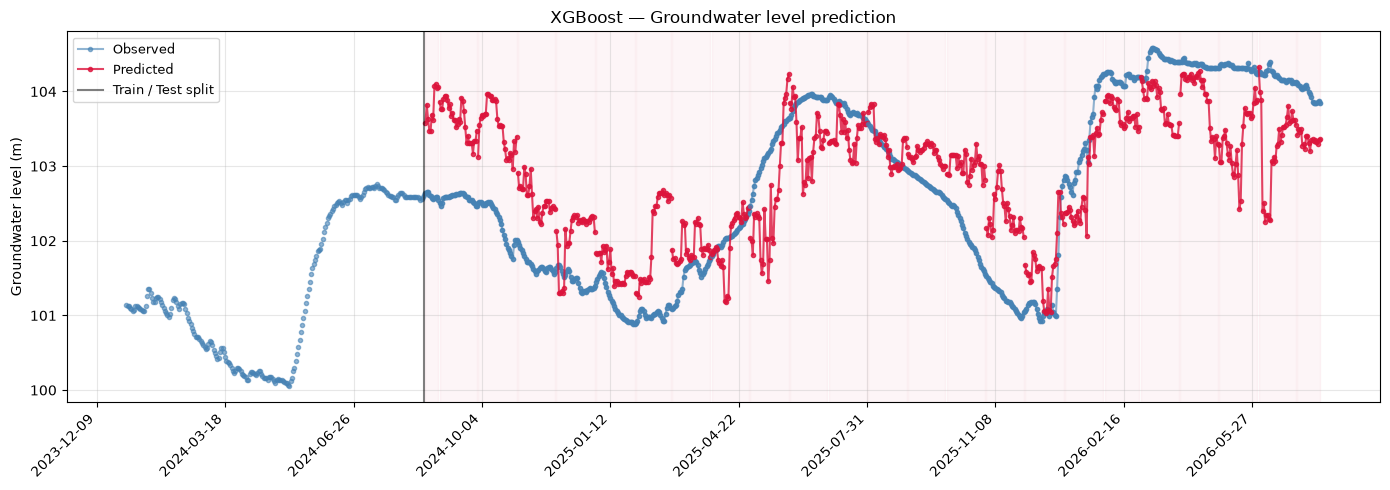

In [38]:
def plot_xgboost_rolling(all_preds_df, df_train_init,
                         target_col="niveau_nappe_eau",
                         figsize=(14, 5),
                         plot_start=None, plot_end=None):
    """
    Visualisation des résultats walk-forward XGBoost.
    - Observed en bleu avec ronds
    - Predicted en rouge avec ronds
    - plot_start / plot_end : bornes du graphique
    """
    # --- Filtrage ---
    train_plot = df_train_init.copy()
    if plot_start:
        train_plot = train_plot[train_plot.index >= pd.Timestamp(plot_start)]
    if plot_end:
        train_plot = train_plot[train_plot.index <= pd.Timestamp(plot_end)]

    preds_plot = all_preds_df.copy()
    if plot_start:
        preds_plot = preds_plot[preds_plot.index >= pd.Timestamp(plot_start)]
    if plot_end:
        preds_plot = preds_plot[preds_plot.index <= pd.Timestamp(plot_end)]

    # --- Figure ---
    fig, ax = plt.subplots(figsize=figsize)

    # Historique train — bleu
    ax.plot(train_plot.index, train_plot[target_col],
            color="steelblue", alpha=0.6,
            marker="o", markersize=3, linestyle="none")

    first_test = True
    first_pred = True
    for _, group in preds_plot.groupby("fold"):

        # y_test — bleu (continuité de la série réelle)
        ax.plot(group.index, group["y_test"],
                color="steelblue", alpha=0.6,
                marker="o", markersize=3,
                label="Observed" if first_test else "")
        first_test = False

        # y_pred — rouge
        ax.plot(group.index, group["y_pred"],
                color="crimson", alpha=0.8,
                marker="o", markersize=3, label="Predicted" if first_pred else "")
        first_pred = False

        ax.axvspan(group.index[0], group.index[-1], alpha=0.04, color="crimson")

    ax.axvline(df_train_init.iloc[:int(len(df_train_init) * 0.8)].index[-1],
               color="black", alpha=0.5,
               label="Train / Test split")
    ax.set_ylabel("Groundwater level (m)")
    ax.set_title("XGBoost — Groundwater level prediction")
    ax.legend(loc="upper left", fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(12))
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()


# ── Exécution ──────────────────────────────────────────────────────────────────
all_preds_df, metrics_df, summary_df = xgboost_rolling_monthly(df)

plot_xgboost_rolling(
    all_preds_df  = all_preds_df,
    df_train_init = df,
    plot_start    = "2024-01-01",  # ← à modifier si besoin
    plot_end      = None           # ← à modifier si besoin
)

Dataset total : 3487 jours
Train initial : 2017-01-01 → 2024-08-20 (2789 jours)
Pool test     : 2024-08-21 → 2026-07-19 (698 jours)

Nombre de mois : 24

Fold 01 | 2024-08 | n_train=2789 | var=0.0014 | biais=+1.183 | R²_test=-1181.590 | MAPE=1.15%
Fold 02 | 2024-09 | n_train=2800 | var=0.0032 | biais=+1.049 | R²_test=-373.105 | MAPE=1.02%
Fold 03 | 2024-10 | n_train=2830 | var=0.0712 | biais=+1.275 | R²_test=-22.981 | MAPE=1.25%
Fold 04 | 2024-11 | n_train=2861 | var=0.0142 | biais=+0.867 | R²_test=-55.430 | MAPE=0.85%
Fold 05 | 2024-12 | n_train=2891 | var=0.0146 | biais=+0.600 | R²_test=-38.023 | MAPE=0.68%
Fold 06 | 2025-01 | n_train=2922 | var=0.0608 | biais=+0.458 | R²_test=-2.905 | MAPE=0.45%
Fold 07 | 2025-02 | n_train=2953 | var=0.0041 | biais=+1.029 | R²_test=-342.062 | MAPE=1.02%
Fold 08 | 2025-03 | n_train=2981 | var=0.0471 | biais=+0.398 | R²_test=-3.733 | MAPE=0.39%
Fold 09 | 2025-04 | n_train=3012 | var=0.0264 | biais=-0.084 | R²_test=-3.431 | MAPE=0.22%
Fold 10 | 2025-05

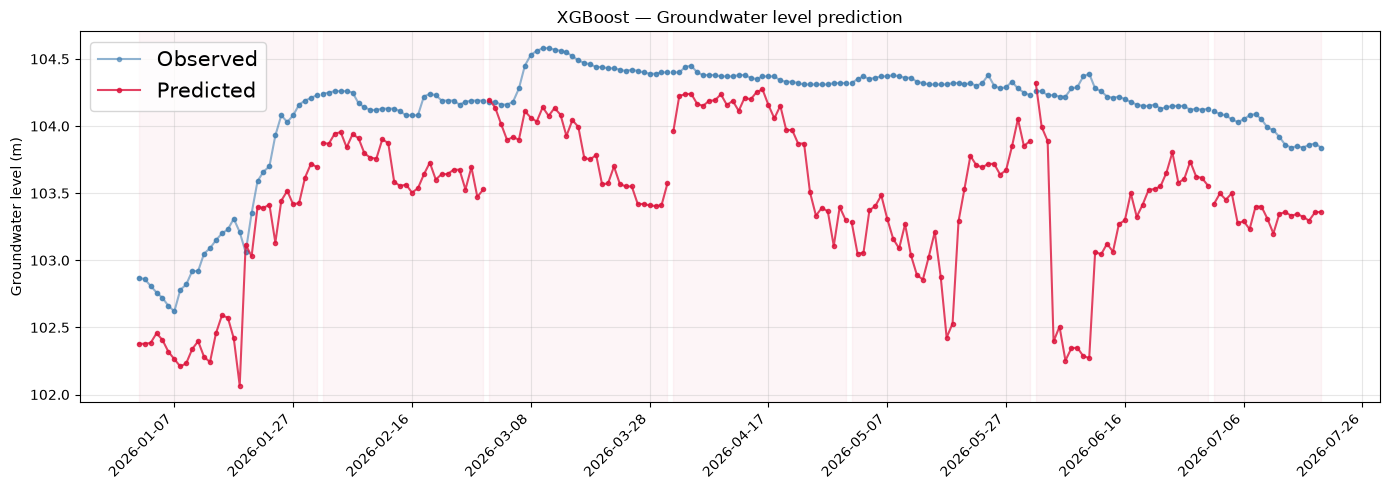

In [45]:
def plot_xgboost_rolling(all_preds_df, df_train_init,
                         target_col="niveau_nappe_eau",
                         figsize=(14, 5),
                         plot_start=None, plot_end=None):
    """
    Visualisation des résultats walk-forward XGBoost.
    - Observed en bleu avec ronds
    - Predicted en rouge avec ronds
    - plot_start / plot_end : bornes du graphique
    """
    # --- Filtrage ---
    train_plot = df_train_init.copy()
    if plot_start:
        train_plot = train_plot[train_plot.index >= pd.Timestamp(plot_start)]
    if plot_end:
        train_plot = train_plot[train_plot.index <= pd.Timestamp(plot_end)]

    preds_plot = all_preds_df.copy()
    if plot_start:
        preds_plot = preds_plot[preds_plot.index >= pd.Timestamp(plot_start)]
    if plot_end:
        preds_plot = preds_plot[preds_plot.index <= pd.Timestamp(plot_end)]

    # --- Figure ---
    fig, ax = plt.subplots(figsize=figsize)

    # Historique train — bleu
    ax.plot(train_plot.index, train_plot[target_col],
            color="steelblue", alpha=0.6,
            marker="o", markersize=3, linestyle="none")

    first_test = True
    first_pred = True
    for _, group in preds_plot.groupby("fold"):

        # y_test — bleu (continuité de la série réelle)
        ax.plot(group.index, group["y_test"],
                color="steelblue", alpha=0.6,
                marker="o", markersize=3,
                label="Observed" if first_test else "")
        first_test = False

        # y_pred — rouge
        ax.plot(group.index, group["y_pred"],
                color="crimson", alpha=0.8,
                marker="o", markersize=3, label="Predicted" if first_pred else "")
        first_pred = False

        ax.axvspan(group.index[0], group.index[-1], alpha=0.04, color="crimson")

    #ax.axvline(df_train_init.iloc[:int(len(df_train_init) * 0.8)].index[-1],
    #           color="black", alpha=0.5,
    #           label="Train / Test split")
    ax.set_ylabel("Groundwater level (m)")
    ax.set_title("XGBoost — Groundwater level prediction")
    ax.legend(loc="upper left", fontsize=15)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(plt.MaxNLocator(12))
    fig.autofmt_xdate(rotation=45)
    plt.tight_layout()
    plt.show()


# ── Exécution ──────────────────────────────────────────────────────────────────
all_preds_df, metrics_df, summary_df = xgboost_rolling_monthly(df)

plot_xgboost_rolling(
    all_preds_df  = all_preds_df,
    df_train_init = df,
    plot_start    = "2026-01-01",
    plot_end      = None
)